In [13]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import xgboost as xgb
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from src.processing import Processing
import config
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from ngboost import NGBClassifier

from src.balance import drop_mice_group, balance_classes_by_undersampling, balance_classes_by_undersampling_features_and_target, balance_before_merge, oversample_and_merge, smote_undersample_and_merge

In [14]:
# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FEATURES_3_GROUPS)
dataclass.read()
df = dataclass.preprocess()

# Step 2: Separate the features (X) and the target (y)
X = df.drop(columns=['group_name'])  # Features
y = df['group_name']  # Target
print('Original value counts for the whole dataset:')
print(y.value_counts())

# Step 3: Split the data into training, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the training+validation set into 70% training and 10% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42) # Final split: 0.7 train, 0.1 val, 0.2 test
print('Value counts in training set:')
print(y_train.value_counts())

# Step 4: Balance the training set using undersampling
X_train, y_train = oversample_and_merge(X_train, y_train)
print('Value counts after balancing (training set):')
print(y_train.value_counts())

# Step 5: Merge group 1 (relapse) and group 2 (control) in validation and test sets
# Validation set
y_val = y_val.replace({2: 1})  # Merge group 1 (relapse) and group 2 (control)
# print('Value counts in validation set after merging:')
# print(y_val.value_counts())

# Test set
y_test = y_test.replace({2: 1})  # Merge group 1 (relapse) and group 2 (control)
# print('Value counts in test set after merging:')
# print(y_test.value_counts())

# Step 5: Define the XGBoost model with class weights
model = NGBClassifier(random_state=42)

# Step 6: Define the parameters for hyperparameter tuning (optional)
param_grid = {
    'n_estimators': [200],  # Número de boosting rounds
    'max_depth': [4],  # Profundidad máxima de los árboles
    'learning_rate': [0.1],  # Tasa de aprendizaje
    'colsample_bytree': [1.0],  # Proporción de columnas a utilizar por árbol
    'subsample': [0.7]  # Proporción de datos a usar para construir cada árbol
}

# Step 7: Use GridSearchCV for cross-validation (10 folds)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=10,  # 10-fold cross-validation
    scoring='f1_macro',
    n_jobs=-1,  # Use all available CPU cores
    verbose=1  # Print the process details
)

# Train the model on the original training set (no resampling)
grid_search.fit(X_train, y_train)

# You can now evaluate the performance on the validation and test sets.


Original value counts for the whole dataset:
group_name
1    232
2     84
0     66
Name: count, dtype: int64
Value counts in training set:
group_name
1    154
2     69
0     43
Name: count, dtype: int64
Value counts after balancing (training set):
group_name
1    223
0    223
Name: count, dtype: int64
Fitting 10 folds for each of 1 candidates, totalling 10 fits
[iter 0] loss=0.6931 val_loss=0.0000 scale=4.0000 norm=8.0000
[iter 100] loss=0.1246 val_loss=0.0000 scale=0.0001 norm=0.0001


GridSearchCV(cv=10,
             estimator=NGBClassifier(random_state=RandomState(MT19937) at 0x1AF40752540),
             n_jobs=-1,
             param_grid={'colsample_bytree': [1.0], 'learning_rate': [0.1],
                         'max_depth': [4], 'n_estimators': [200],
                         'subsample': [0.7]},
             scoring='f1_macro', verbose=1)

In [15]:
# Print the best model and hyperparameters found
best_model = grid_search.best_estimator_
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation f1_macro: {grid_search.best_score_ * 100:.2f}%")

# Save the best model to a file
joblib.dump(best_model, 'best_xgboost_model.pkl')
print("Best model saved as 'best_xgboost_model.pkl'")

Best parameters found: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.7}
Best cross-validation f1_macro: 91.05%
Best model saved as 'best_xgboost_model.pkl'


Accuracy on the training set: 94.84%
F1 score on the training set: 94.84%
Accuracy on the validation set: 71.79%
F1 score on the validation set: 54.60%
Accuracy on the test set: 85.71%
F1 score on the test set: 77.79%
Classification report on the test set:

              precision    recall  f1-score   support

           0       0.71      0.59      0.65        17
           1       0.89      0.93      0.91        60

    accuracy                           0.86        77
   macro avg       0.80      0.76      0.78        77
weighted avg       0.85      0.86      0.85        77



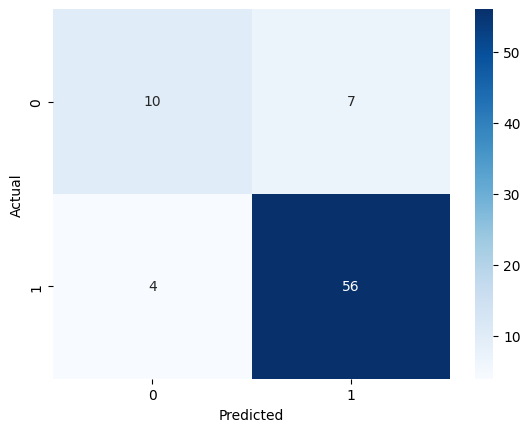

In [16]:
# Step 7: Evaluate the best model on the training set
y_train_pred = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='macro')
#train_roc_auc = roc_auc_score(y_train, best_model.predict_proba(X_train), multi_class='ovr', average='weighted')
print(f'Accuracy on the training set: {train_accuracy * 100:.2f}%')
print(f'F1 score on the training set: {train_f1 * 100:.2f}%')
#print(f'ROC AUC on the training set: {train_roc_auc * 100:.2f}%')

# Step 8: Evaluate the best model on the validation set
y_val_pred = best_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='macro')
#val_roc_auc = roc_auc_score(y_val, best_model.predict_proba(X_val), multi_class='ovr', average='weighted')
print(f'Accuracy on the validation set: {val_accuracy * 100:.2f}%')
print(f'F1 score on the validation set: {val_f1 * 100:.2f}%')
#print(f'ROC AUC on the validation set: {val_roc_auc * 100:.2f}%')

# Step 9: Evaluate the best model on the test set
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')
#test_roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test), multi_class='ovr', average='weighted')
print(f'Accuracy on the test set: {test_accuracy * 100:.2f}%')
print(f'F1 score on the test set: {test_f1 * 100:.2f}%')
#print(f'ROC AUC on the test set: {test_roc_auc * 100:.2f}%')
print(f'Classification report on the test set:\n')
print(classification_report(y_test, y_test_pred))

# Step 10: Plot the confusion matrix
confusion_matrix = pd.crosstab(y_test, y_test_pred, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.show()


97


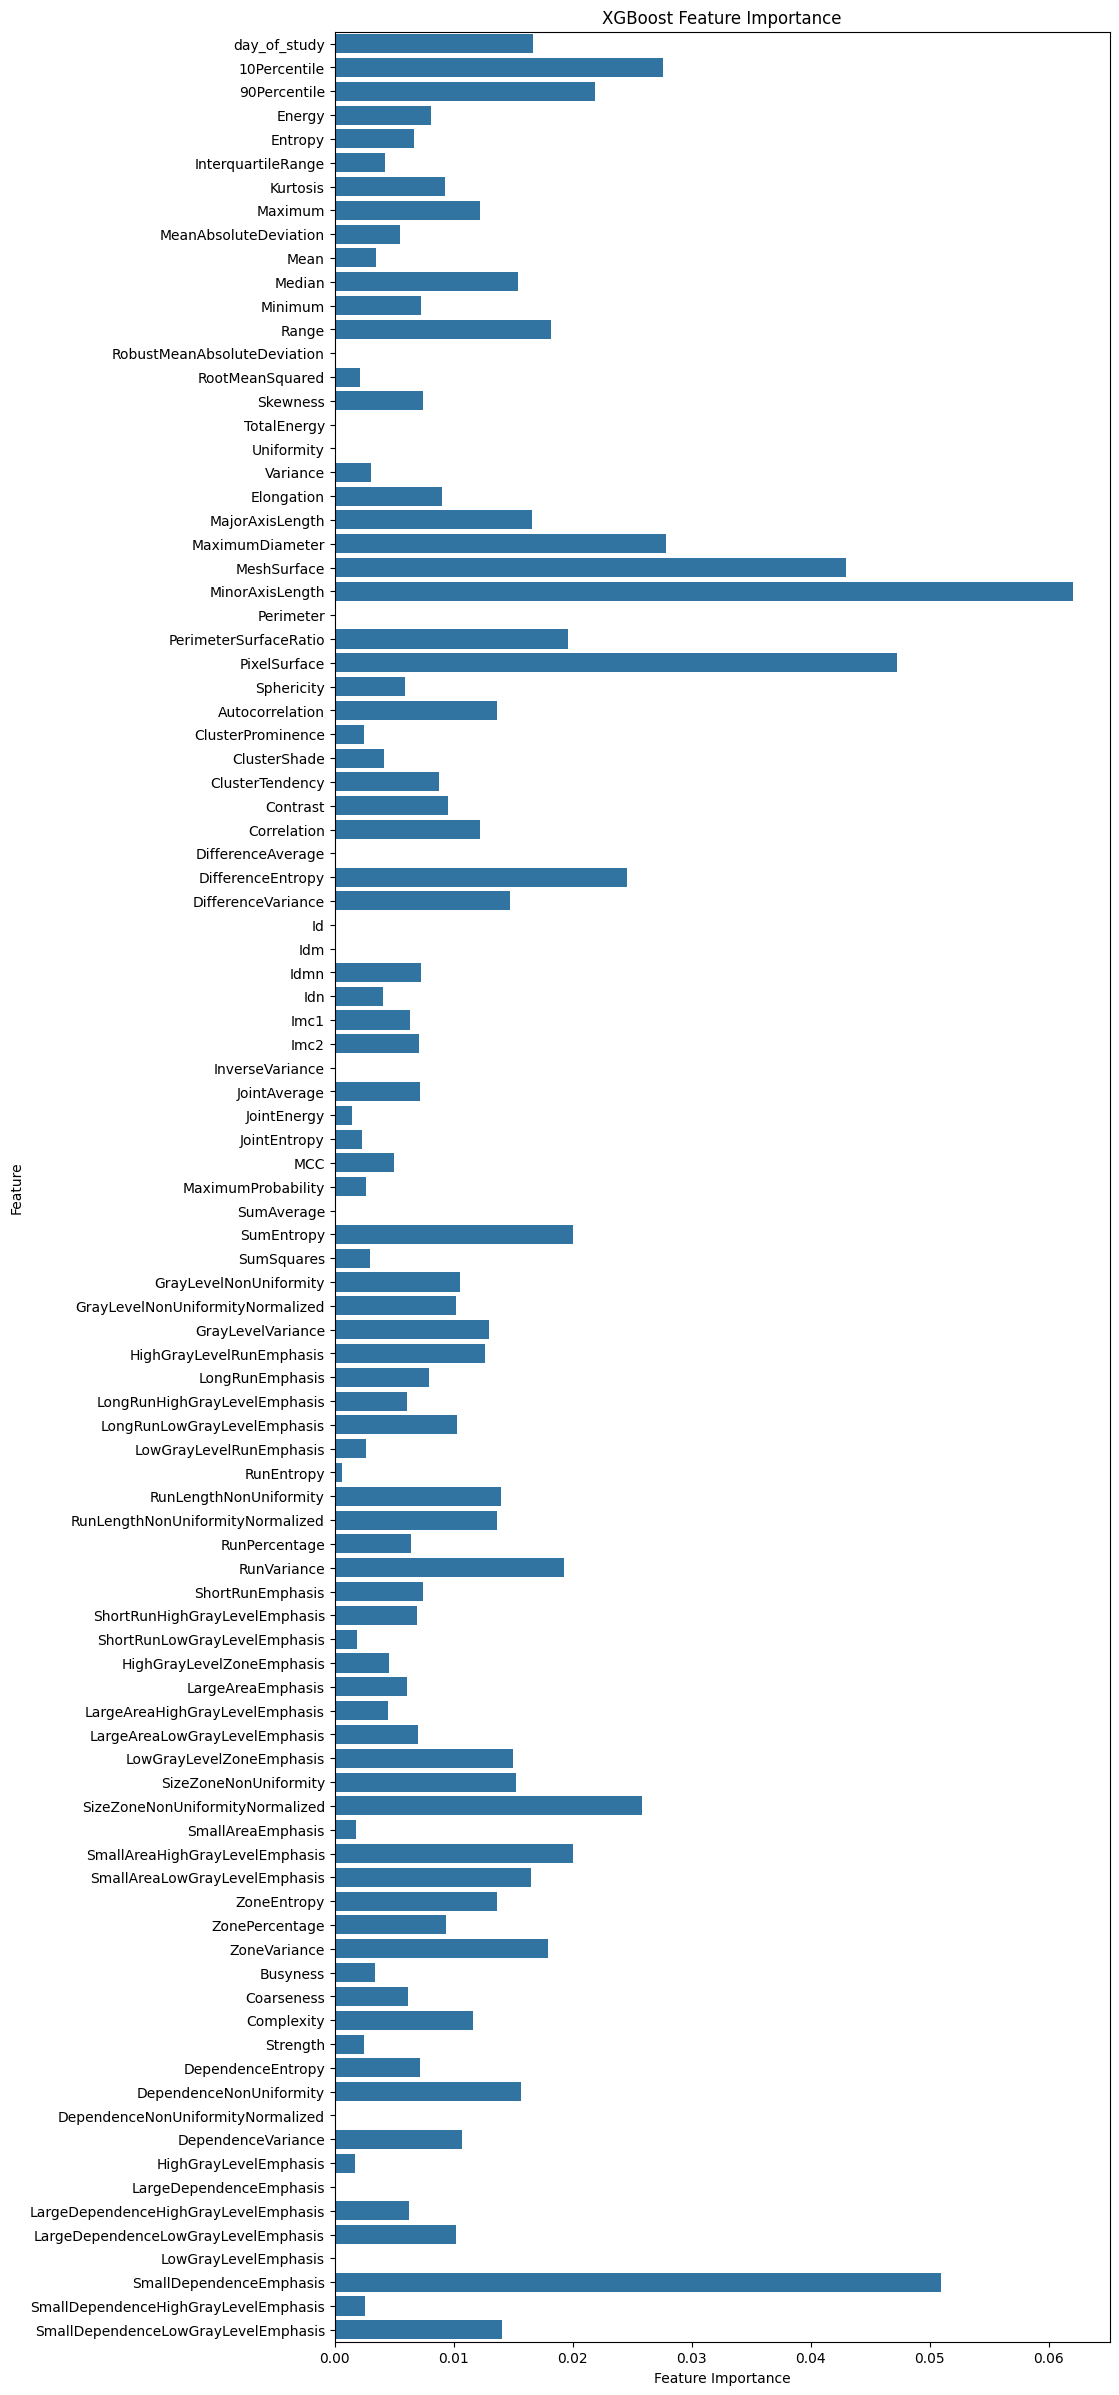

In [5]:
importances_best_model = best_model.feature_importances_

# Plot the feature importance
print(len(importances_best_model))

plt.figure(figsize=(10, 30))
sns.barplot(x=importances_best_model, y=X.columns)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.show()

In [6]:
# Number of top features to select (e.g., the 10 most important)
num_top_features = 10

# Select the N most important features based on feature importance from XGBoost
important_features_indices = np.argsort(importances_best_model)[-num_top_features:]  # The most important at the end
X_train_selected = X_train.iloc[:, important_features_indices]
X_val_selected = X_val.iloc[:, important_features_indices]
X_test_selected = X_test.iloc[:, important_features_indices]

# Display the selected features' names
print(X_train.columns[important_features_indices])

# Train the model using only the selected features
model_selected = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.2, random_state=42)  # You can reuse the best parameters
model_selected.fit(X_train_selected, y_train)

# Evaluate the model on the validation set
y_val_pred = model_selected.predict(X_val_selected)
print(f'Accuracy on the validation set: {accuracy_score(y_val, y_val_pred) * 100:.2f}%')
class_report = classification_report(y_val, y_val_pred)
print(f'Classification report on the validation set (selected features):\n{class_report}')

# Evaluate the model on the test set
y_test_pred = model_selected.predict(X_test_selected)
print(f'Accuracy on the test set: {accuracy_score(y_test, y_test_pred) * 100:.2f}%')
class_report = classification_report(y_test, y_test_pred)
print(f'Classification report on the test set (selected features):\n{class_report}')


Index(['SumEntropy', '90Percentile', 'DifferenceEntropy',
       'SizeZoneNonUniformityNormalized', '10Percentile', 'MaximumDiameter',
       'MeshSurface', 'PixelSurface', 'SmallDependenceEmphasis',
       'MinorAxisLength'],
      dtype='object')
Accuracy on the validation set: 84.62%
Classification report on the validation set (selected features):
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         6
           1       0.91      0.91      0.91        33

    accuracy                           0.85        39
   macro avg       0.70      0.70      0.70        39
weighted avg       0.85      0.85      0.85        39

Accuracy on the test set: 80.52%
Classification report on the test set (selected features):
              precision    recall  f1-score   support

           0       0.62      0.29      0.40        17
           1       0.83      0.95      0.88        60

    accuracy                           0.81        77
   macro a

Accuracy on the validation set (selected features): 82.05%
              precision    recall  f1-score   support

           0       0.43      0.50      0.46         6
           1       0.91      0.88      0.89        33

    accuracy                           0.82        39
   macro avg       0.67      0.69      0.68        39
weighted avg       0.83      0.82      0.83        39

Accuracy on the test set (selected features): 84.42%
              precision    recall  f1-score   support

           0       0.63      0.71      0.67        17
           1       0.91      0.88      0.90        60

    accuracy                           0.84        77
   macro avg       0.77      0.79      0.78        77
weighted avg       0.85      0.84      0.85        77

10


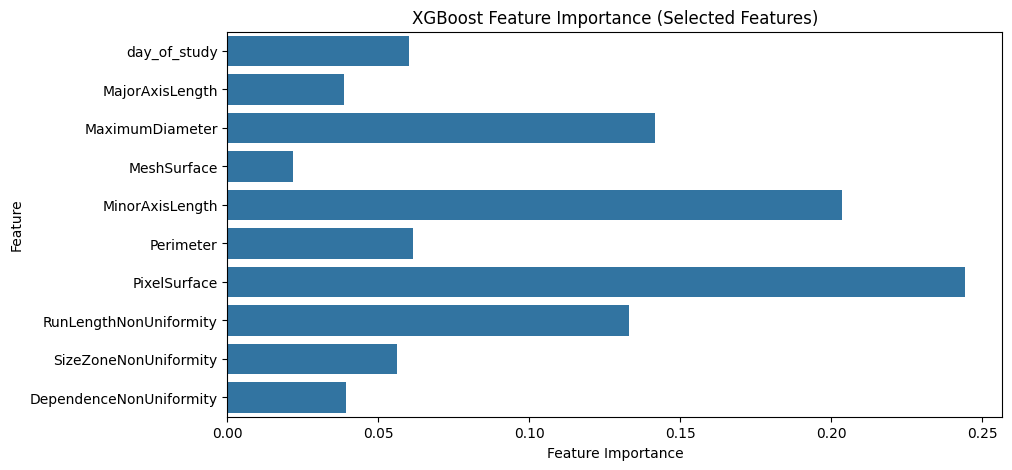

In [7]:
# Apply feature selection

# Select the top 10 features
selector = SelectKBest(chi2, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)

# Train a new XGBoost model on the selected features
model_selected = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.01, random_state=42 )# Best parameters found: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}
model_selected.fit(X_train_selected, y_train)

# Evaluate the model on the validation set
y_val_pred = model_selected.predict(X_val_selected)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Accuracy on the validation set (selected features): {val_accuracy * 100:.2f}%')
print(classification_report(y_val, y_val_pred))

# Evaluate the model on the test set
y_test_pred = model_selected.predict(X_test_selected)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy on the test set (selected features): {test_accuracy * 100:.2f}%')
print(classification_report(y_test, y_test_pred))

# Plot the feature importance
print(len(model_selected.feature_importances_))

plt.figure(figsize=(10, 5))
sns.barplot(x=model_selected.feature_importances_, y=X.columns[selector.get_support()])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance (Selected Features)')
plt.show()

In [10]:
# Train a SVM model
svm_model = svm.SVC()

# Define the parameters for the Grid Search
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Types of kernel
    'gamma': ['scale', 'auto']  # For non-linear kernels
}

# Configure the Grid Search with cross-validation
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, 
                           scoring='f1_macro', cv=10, n_jobs=-1)

# Fit the Grid Search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f'Best parameters found: {best_params}')

# Predict on the validation set
y_val_pred = best_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Accuracy on the validation set: {val_accuracy * 100:.2f}%')
c_report = classification_report(y_val, y_val_pred)
print(f'Classification report on the validation set:\n{c_report}')

# Predict on the test set
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy on the test set: {test_accuracy * 100:.2f}%')
c_report = classification_report(y_test, y_test_pred)
print(f'Classification report on the test set:\n{c_report}')

Best parameters found: {'C': 100, 'gamma': 'auto', 'kernel': 'poly'}
Accuracy on the validation set: 64.10%
Classification report on the validation set:
              precision    recall  f1-score   support

           0       0.10      0.17      0.12         6
           1       0.83      0.73      0.77        33

    accuracy                           0.64        39
   macro avg       0.46      0.45      0.45        39
weighted avg       0.72      0.64      0.67        39

Accuracy on the test set: 77.92%
Classification report on the test set:
              precision    recall  f1-score   support

           0       0.50      0.53      0.51        17
           1       0.86      0.85      0.86        60

    accuracy                           0.78        77
   macro avg       0.68      0.69      0.69        77
weighted avg       0.78      0.78      0.78        77



In [14]:
# Define the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Define the parameters for the Grid Search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
    'max_features': [None, 'sqrt', 'log2']  # The number of features to consider when looking for the best split
}

# Configure the Grid Search with cross-validation
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           scoring='accuracy', cv=10, n_jobs=-1)

# Fit the Grid Search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f'Best parameters found: {best_params}')

# Predict on the validation set
y_val_pred = best_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Accuracy on the validation set: {val_accuracy * 100:.2f}%')
c_report = classification_report(y_val, y_val_pred)
print(f'Classification report on the validation set:\n{c_report}')

# Predict on the test set
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy on the test set: {test_accuracy * 100:.2f}%')
c_report = classification_report(y_test, y_test_pred)
print(f'Classification report on the test set:\n{c_report}')

Best parameters found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy on the validation set: 82.05%
Classification report on the validation set:
              precision    recall  f1-score   support

           0       0.43      0.50      0.46         6
           1       0.91      0.88      0.89        33

    accuracy                           0.82        39
   macro avg       0.67      0.69      0.68        39
weighted avg       0.83      0.82      0.83        39

Accuracy on the test set: 80.52%
Classification report on the test set:
              precision    recall  f1-score   support

           0       0.60      0.35      0.44        17
           1       0.84      0.93      0.88        60

    accuracy                           0.81        77
   macro avg       0.72      0.64      0.66        77
weighted avg       0.78      0.81      0.79        77

